# Fine-tuning DTrOCR on IAM dataset
This is an example of fine-tuning DTrOCR on IAM dataset handwritten words from [Kaggle](https://www.kaggle.com/datasets/teykaicong/iamondb-handwriting-dataset). IAM Aachen splits can be downloaded [here](https://www.openslr.org/56/).

# Dataset folder structure
```
data/
│
├── images/                              # PNG files
│   ├── 0.png                           
│   │   .
│   │   .
│   │   .
│   └── 1.png                          
│
└── labels/                                # txt files
	├── 0.txt
	.
	.
	.
	└── 1.txt
```

In [ ]:
from pathlib import Path

MODEL='Version4'

EPOCHS=1

LR=1e-4

DATASET_PATH = Path('preprocessed_data/text_renderer_print')

DATASET_PATH.mkdir(parents=True, exist_ok=True)

AUGMENT_DATA = False


In [2]:
import json
from pathlib import Path

if AUGMENT_DATA:
    with open(str(DATASET_PATH / 'labels.json'), 'r') as fp:
        data_dict = json.load(fp)['labels']

    print(f"{len(data_dict.items())} dict elements")

2000000 dict elements


In [3]:
from util.augmentation import augment_dataset
from util.data_processing import save_labels

if AUGMENT_DATA:
    augment_dataset(data_dict, 3, 3, 3, 'preprocessed_data/text_renderer_print/images/')
    save_labels(data_dict, DATASET_PATH / 'augmented_labels.json')

In [8]:
import json
from pathlib import Path

with open(str(DATASET_PATH / 'augmented_labels.json'), 'r') as fp:
    data_dict = json.load(fp)

print(f"{len(data_dict.items())} dict elements")

words_files = list(data_dict.items())
print(words_files[0])

4000000 dict elements
('000000000', '」')


In [9]:
import tqdm
import multiprocessing as mp
import xml.etree.ElementTree as ET
import functools
from PIL import Image
from dataclasses import dataclass
import os

dataset_path = Path('data')


@dataclass
class Word:
    file_path: Path
    transcription: str
    

def get_word(word_file):
    words = []
    words.append(
        Word(
            file_path=str(DATASET_PATH / 'images' / (word_file[0] + '.jpg')),
            transcription=word_file[1]
        )
    )
    return words


with mp.Pool(processes=mp.cpu_count()) as pool:
    words_list = list(
        tqdm.tqdm(
            pool.imap(get_word, words_files), 
            total=len(words_files),
            desc='Building dataset'
        )
    )
    words = [word for words_array in words_list for word in words_array]
print(words[0])

Building dataset: 100%|██████████| 4000000/4000000 [13:37<00:00, 4894.16it/s] 


Word(file_path='preprocessed_data/text_renderer_print/images/000000000.jpg', transcription='」')


In [10]:
str(DATASET_PATH / 'images' / (words_files[2000000][0] + '.jpg'))

'preprocessed_data/text_renderer_print/images/000333333-1.jpg'

# Train test split

In [ ]:
from random import shuffle
import numpy as np

shuffle(words)

train_word_records, test_word_records = np.split(words, [int(len(words)*0.9)])
print(f'Train size: {len(train_word_records)}; Test size: {len(test_word_records)}')

Train size: 3200000; Validation size: 400000; Test size: 400000


# Build dataset and dataloader

In [ ]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig
from pathlib import Path

from torch.utils.data import Dataset
    
class IAMDataset(Dataset):
    def __init__(self, words: list[Word], config: DTrOCRConfig):
        super(IAMDataset, self).__init__()
        self.words = words
        self.processor = DTrOCRProcessor(config, add_eos_token=True, add_bos_token=True)
        
    def __len__(self):
        return len(self.words)
    
    def __getitem__(self, item):
        inputs = self.processor(
            images=Image.open(self.words[item].file_path).convert('RGB'),
            texts=self.words[item].transcription,
            padding='max_length',
            return_tensors="pt",
            return_labels=True,
        )
        return {
            'pixel_values': inputs.pixel_values[0],
            'input_ids': inputs.input_ids[0],
            'input_attention_mask': inputs.input_attention_mask[0],
            'label_attention_mask': inputs.label_attention_mask[0],
            'labels': inputs.labels[0]
        }

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)

train_data = IAMDataset(words=train_word_records, config=config)
test_data = IAMDataset(words=test_word_records, config=config)

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will b

In [ ]:
from torch.utils.data import DataLoader
import multiprocessing as mp

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=mp.cpu_count())

# Model

In [14]:
import torch
import os
torch.set_float32_matmul_precision('high')

from dtrocr.model import DTrOCRLMHeadModel

model = DTrOCRLMHeadModel(config)
model = torch.compile(model)
if os.path.exists(f'../models/{MODEL}.pt'):
    model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))
model.to(device=0)

OptimizedModule(
  (_orig_mod): DTrOCRLMHeadModel(
    (transformer): DTrOCRModel(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(4, 8), stride=(4, 8))
      )
      (token_embedding): Embedding(32000, 768)
      (positional_embedding): Embedding(256, 768)
      (hidden_layers): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2SdpaAttention(
            (c_attn): Conv1D()
            (c_proj): Conv1D()
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D()
            (c_proj): Conv1D()
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)


# Training

In [ ]:
from typing import Tuple
import tqdm

def evaluate_model(model: torch.nn.Module, dataloader: DataLoader) -> Tuple[float, float]:
    # set model to evaluation mode
    model.eval()
    
    losses, accuracies = [], []
    with torch.no_grad():
        for inputs in tqdm.tqdm(dataloader, total=len(dataloader), desc=f'Evaluating test set'):
            inputs = send_inputs_to_device(inputs, device=0)
            outputs = model(**inputs)
            
            losses.append(outputs.loss.item())
            accuracies.append(outputs.accuracy.item())
    
    loss = sum(losses) / len(losses)
    accuracy = sum(accuracies) / len(accuracies)
    
    # set model back to training mode
    model.train()
    
    return loss, accuracy

def send_inputs_to_device(dictionary, device):
    return {key: value.to(device=device) if isinstance(value, torch.Tensor) else value for key, value in dictionary.items()}

use_amp = True
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
optimiser = torch.optim.Adam(params=model.parameters(), lr=LR)

train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []
for epoch in range(EPOCHS):
    epoch_losses, epoch_accuracies = [], []
    for inputs in tqdm.tqdm(train_dataloader, total=len(train_dataloader), desc=f'Epoch {epoch + 1}'):
        
        # set gradients to zero
        optimiser.zero_grad()
        
        # send inputs to same device as model
        inputs = send_inputs_to_device(inputs, device=0)
        
        # forward pass
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
            outputs = model(**inputs)
        
        # calculate gradients
        scaler.scale(outputs.loss).backward()
        
        # update weights
        scaler.step(optimiser)
        scaler.update()
        
        epoch_losses.append(outputs.loss.item())
        epoch_accuracies.append(outputs.accuracy.item())
        if (len(epoch_losses)%500000 == 0): 
            torch.save(model.state_dict(), f'../models/{MODEL}.pt')
            print(f"Train loss: {sum(epoch_losses) / len(epoch_losses)}, Train accuracy: {sum(epoch_accuracies) / len(epoch_accuracies)}")
        
        
    # store loss and metrics
    train_losses.append(sum(epoch_losses) / len(epoch_losses))
    train_accuracies.append(sum(epoch_accuracies) / len(epoch_accuracies))
    
    # tests loss and accuracy
    test_loss, test_accuracy = evaluate_model(model, test_dataloader)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
                    
    print(f"Epoch: {epoch + 1} - Train loss: {train_losses[-1]}, Train accuracy: {train_accuracies[-1]}, Test loss: {test_losses[-1]}, Test accuracy: {test_accuracies[-1]}")

Evaluating test set: 100%|██████████| 12500/12500 [52:18<00:00,  3.98it/s]

Epoch: 1 - Train loss: 1.1300794161766023, Train accuracy: 0.799646259009242, Validation loss: 0.9728994667363167, Validation accuracy: 0.8333053951692582, Test loss: 0.9717898469430208, Test accuracy: 0.8337488355112076


# Test

In [16]:
from dtrocr.model import DTrOCRLMHeadModel
from dtrocr.config import DTrOCRConfig
from dtrocr.processor import DTrOCRProcessor
torch.save(model.state_dict(), f'../models/{MODEL}.pt')
# model = DTrOCRLMHeadModel(DTrOCRConfig())
model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [17]:
import matplotlib

matplotlib.rc('font', family='TakaoPGothic')

/home/kane/miniconda3/envs/DTrOCR/lib/python3.12/site-packages/dtrocr-0.3.0-py3.12.egg/dtrocr/model.py:295: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  next_tokens = torch.argmax(torch.nn.functional.softmax(next_token_scores), dim=-1)


ク代、   ク代、


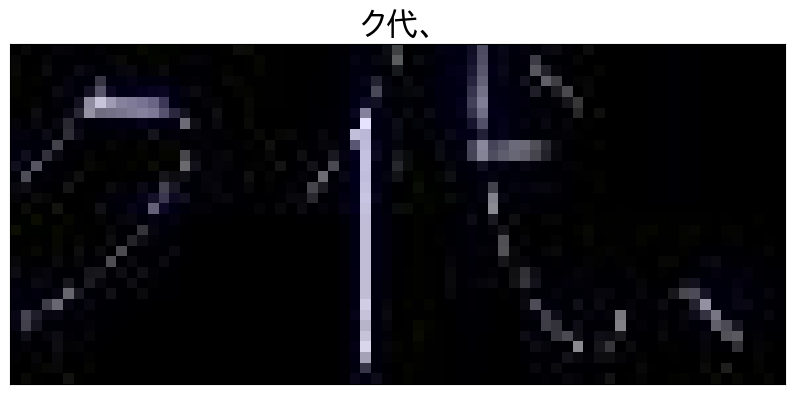

中まで   中まで


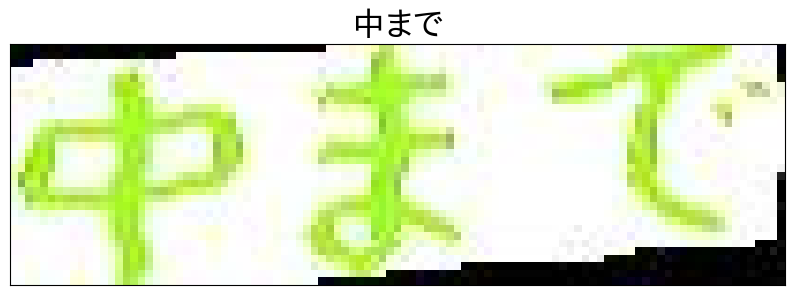

入る   入る


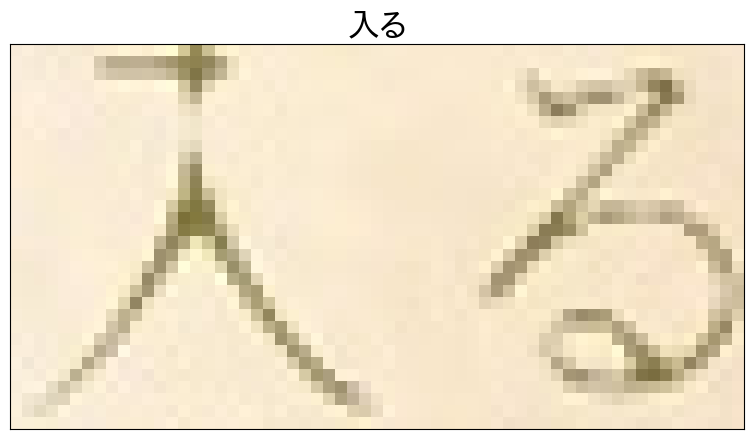

が   が


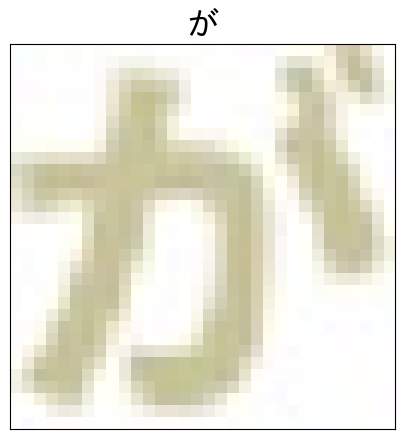

が載っていた   が載っていた


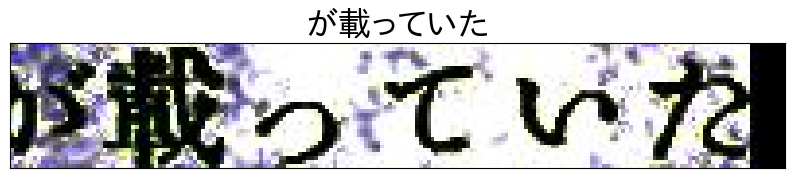

画   画


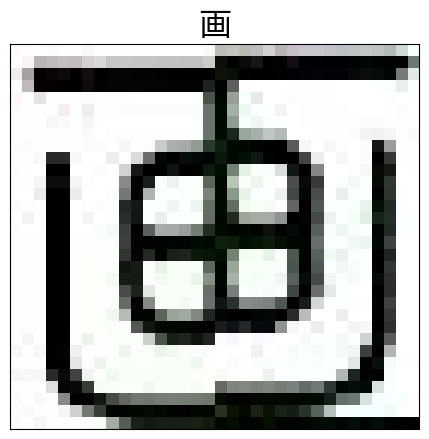

さい   さい


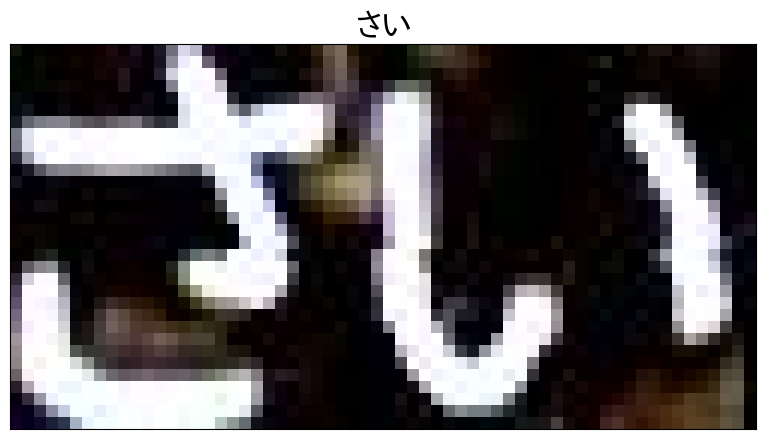

った～。   、


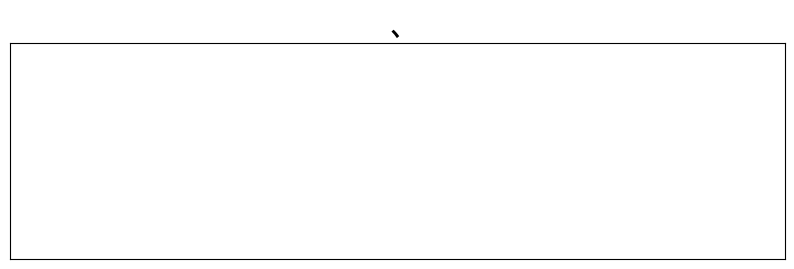

て   て


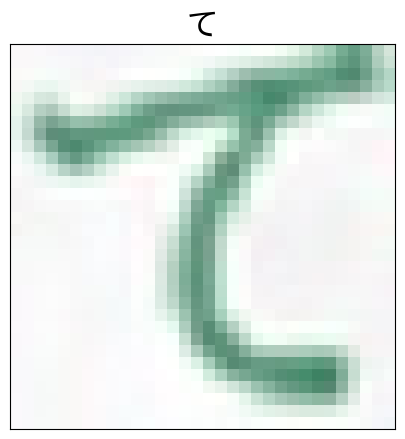

パウ   ム中


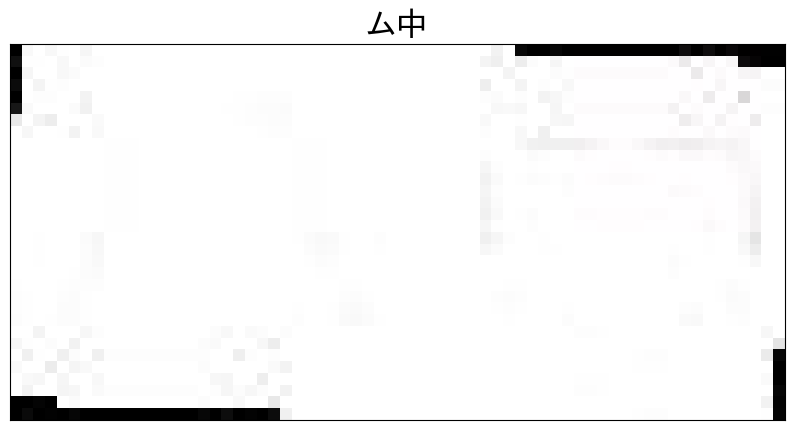

、メールの   、メールの


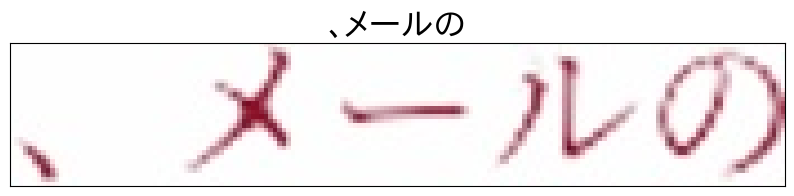

という   という


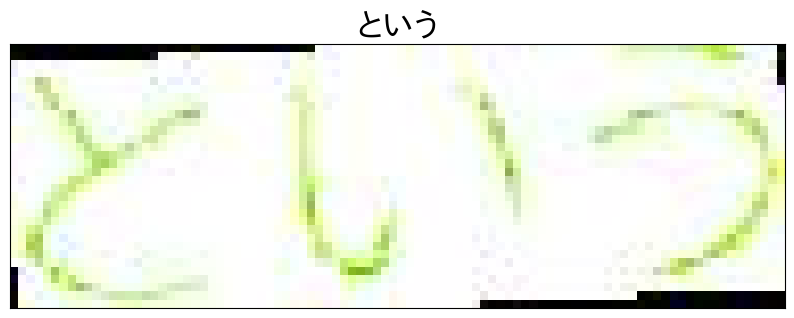

やって   やって


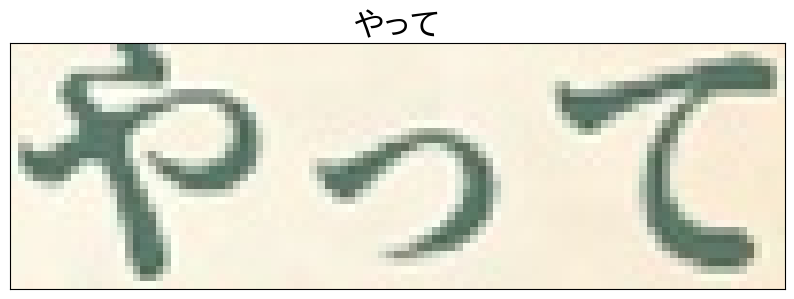

浴   浴


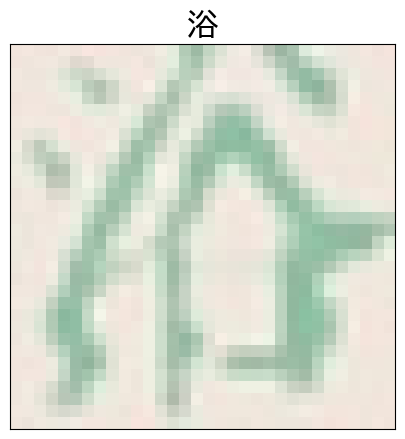

り   う


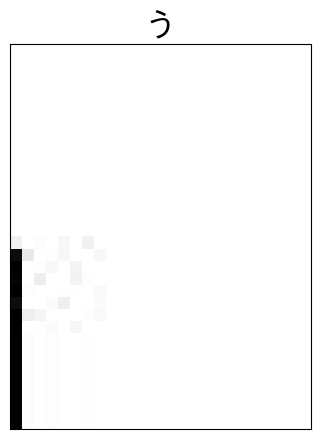

ホテ   ホテ


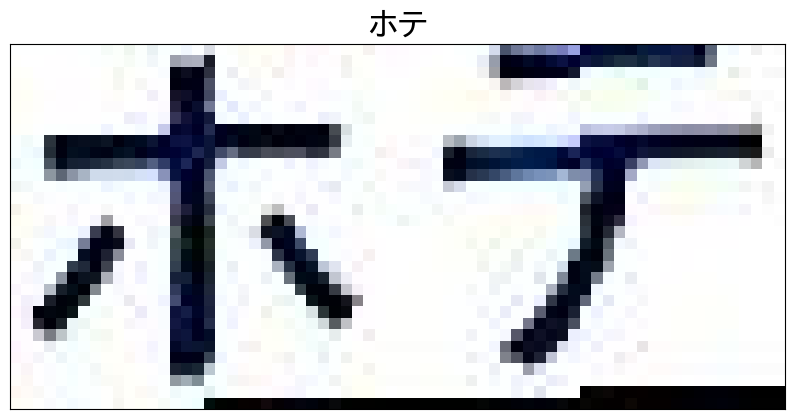

とでも思ったの   と、、と


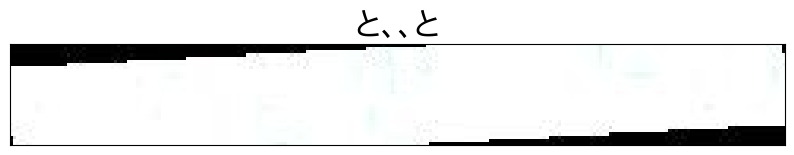

」を   」を


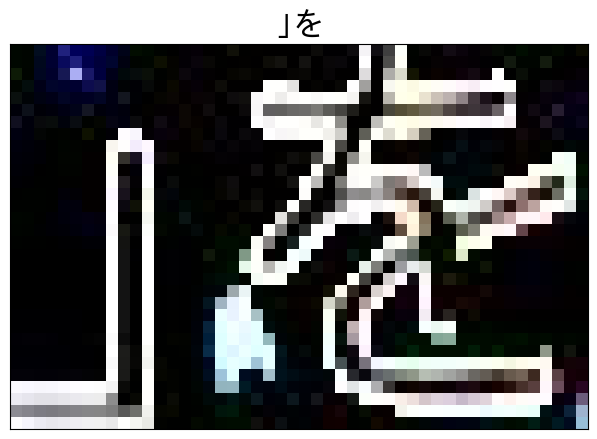

を用意し   を


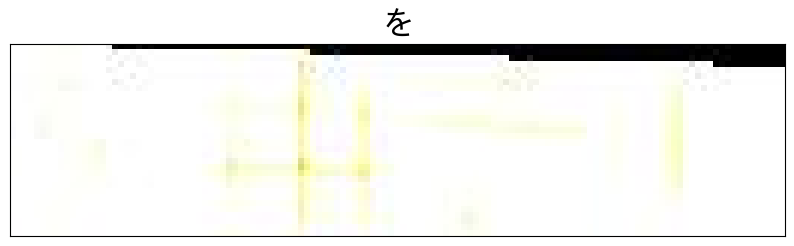

行って   行って


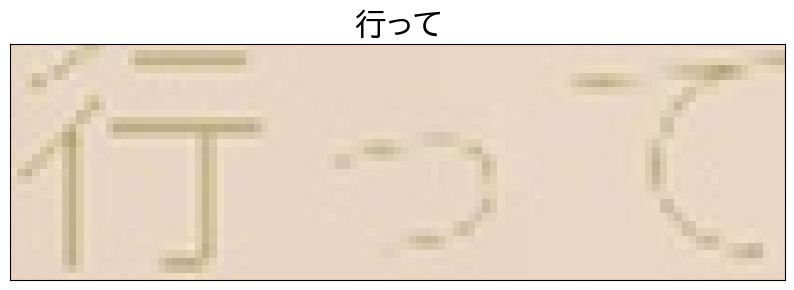

スが   スが


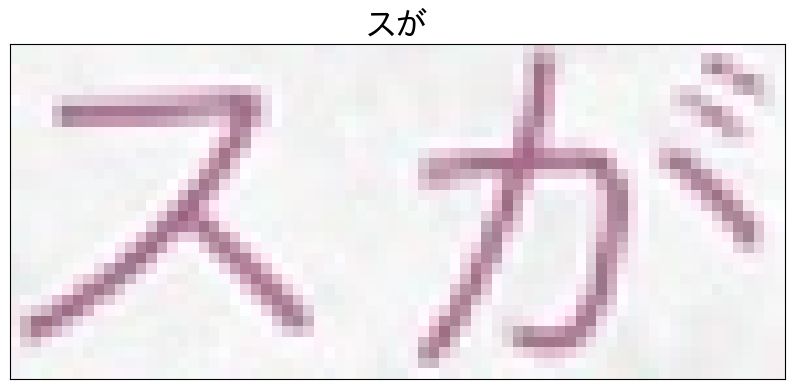

得る術に長けて   得る術長長て


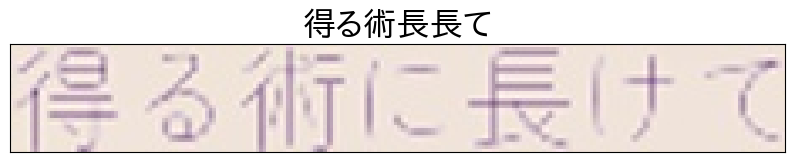

いま   いま


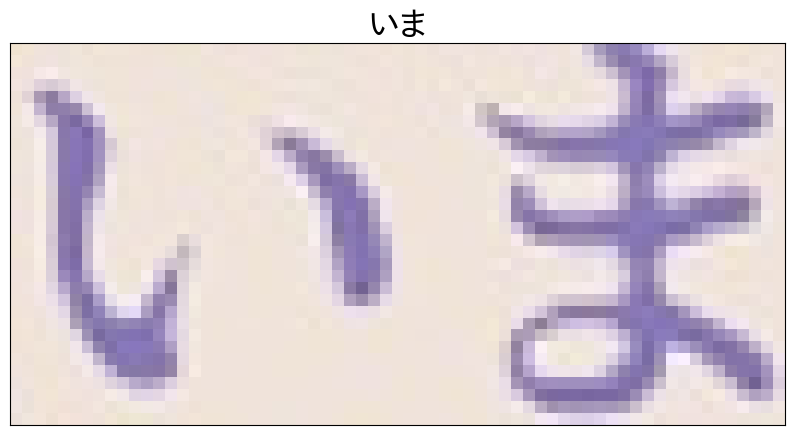

ョン』   ョン


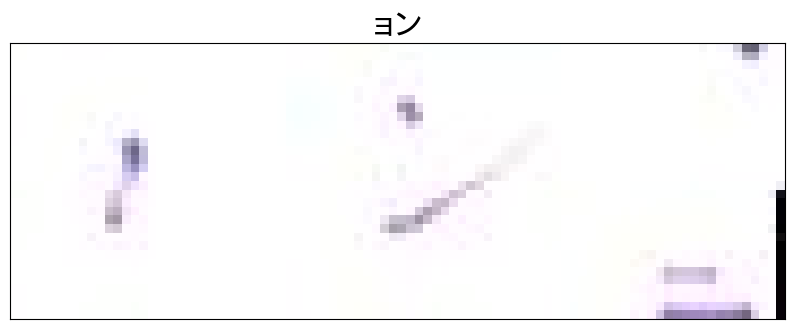

りました☆   りました☆


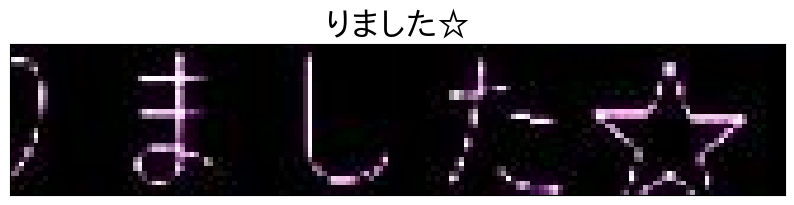

化と確実さを   を。でをを


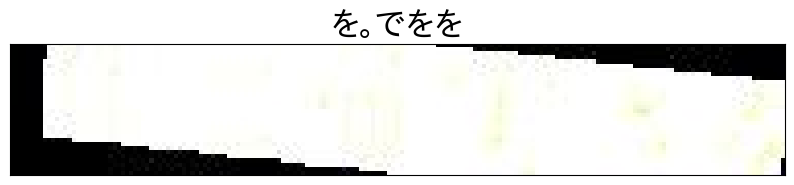

お   


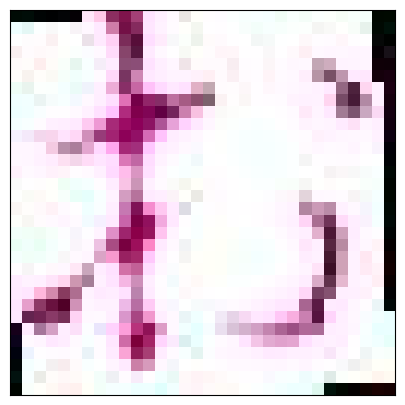

)年   発


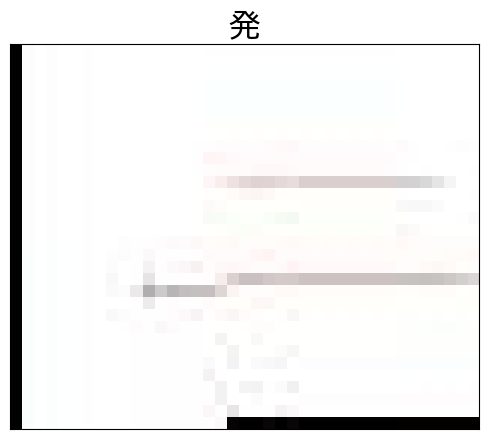

茂木健一   茂木


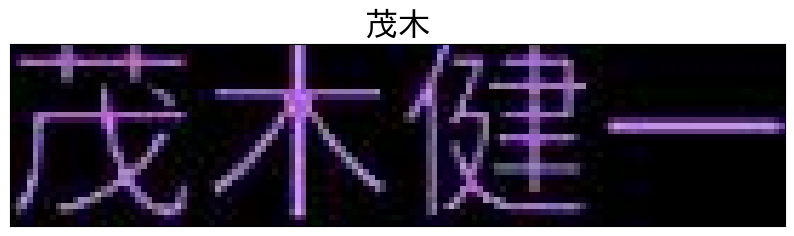

割との事です。   割との事です。


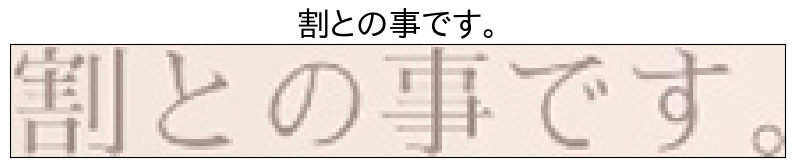

In [18]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

for test_word_record in train_word_records[1000:1030]:
    image_file = test_word_record.file_path
    image = Image.open(image_file).convert('RGB')
    
    inputs = test_processor(
        images=image, 
        texts='',
        return_tensors='pt'
    )
    
    model_output = model.generate(
        inputs, 
        test_processor,
        num_beams=1
    )
    
    predicted_text = test_processor.tokeniser.decode(model_output[0], skip_special_tokens=True)
    
    print(test_word_record.transcription, ' ', predicted_text)
    plt.figure(figsize=(10, 5))
    plt.title(predicted_text, fontsize=24)
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()